In [ ]:
# downloading brain tumor MRI dataset from kaggle
import opendatasets as od
od.download("https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset")

Skipping, found downloaded files in "./brain-tumor-mri-dataset" (use force=True to force download)


In [ ]:
# importing the necessary libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import os

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [ ]:
# checking the dataset folder structure
dataset_path = './brain-tumor-mri-dataset'

for split in ['Training', 'Testing']:
    split_path = os.path.join(dataset_path, split)
    if os.path.exists(split_path):
        print(f"\n{split} set:")
        for category in sorted(os.listdir(split_path)):
            cat_path = os.path.join(split_path, category)
            if os.path.isdir(cat_path):
                count = len(os.listdir(cat_path))
                print(f"  {category}: {count} images")


Training set:
  glioma: 1400 images
  meningioma: 1400 images
  notumor: 1400 images
  pituitary: 1400 images

Testing set:
  glioma: 400 images
  meningioma: 400 images
  notumor: 400 images
  pituitary: 400 images


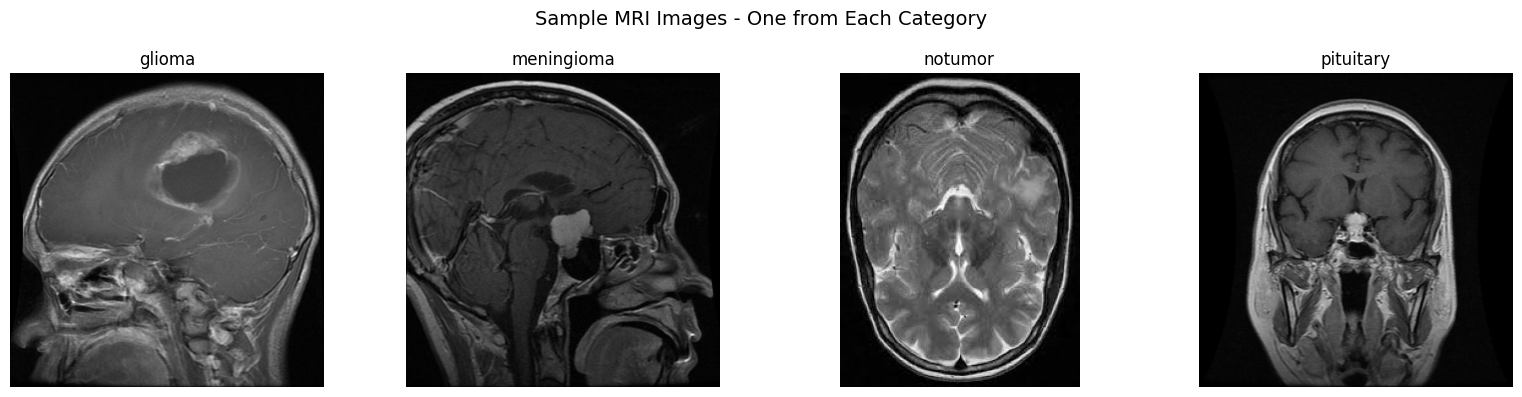

Original image size: (512, 512)
Image mode: L


In [ ]:
# visualizing one sample MRI from each class
from PIL import Image

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, cat in enumerate(class_names):
    img_path = os.path.join('./brain-tumor-mri-dataset/Training', cat)
    img = Image.open(os.path.join(img_path, os.listdir(img_path)[5]))
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(cat, fontsize=12)
    axes[i].axis('off')
plt.suptitle("Sample MRI Images - One from Each Category", fontsize=14)
plt.tight_layout()
plt.show()

# checking original image size
sample_path = './brain-tumor-mri-dataset/Training/glioma'
sample_img = Image.open(os.path.join(sample_path, os.listdir(sample_path)[0]))
print("Original image size:", sample_img.size)
print("Image mode:", sample_img.mode)

In [ ]:
# loading images using ImageDataGenerator
# resizing to 64x64 for faster training on M2 macbook
IMG_SIZE = 64

# data augmentation for training - mild augmentation for MRI images
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    zoom_range=0.05
)

# only rescaling for test data
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    './brain-tumor-mri-dataset/Training',
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=32,
    class_mode='sparse',
    shuffle=True
)

test_data = test_datagen.flow_from_directory(
    './brain-tumor-mri-dataset/Testing',
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

print("\nClass mapping:", train_data.class_indices)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [ ]:
# building CNN model - 3 conv blocks with double conv layers each
# using GlobalAveragePooling2D instead of Flatten to reduce parameters
model = models.Sequential([
    # first conv block - 32 filters
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(64, 64, 1)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # second conv block - 64 filters
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # third conv block - 128 filters
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # global average pooling and dense layers
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # output layer - 4 tumor types with softmax
    layers.Dense(4, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/opt/anaconda3/envs/cancer_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 305,252 (1.16 MB)

 Trainable params: 304,356 (1.16 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
# callbacks - reduce lr on plateau and early stopping
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
early_stop = EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1, mode='max')

# training the model
history = model.fit(train_data,
                    epochs=40,
                    validation_data=test_data,
                    callbacks=[lr_reducer, early_stop])

Epoch 1/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 33s 183ms/step - accuracy: 0.6655 - loss: 0.8301 - val_accuracy: 0.2500 - val_loss: 5.5436 - learning_rate: 0.0010
Epoch 2/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 33s 187ms/step - accuracy: 0.7727 - loss: 0.5937 - val_accuracy: 0.3956 - val_loss: 2.7247 - learning_rate: 0.0010
Epoch 3/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 33s 187ms/step - accuracy: 0.8107 - loss: 0.5003 - val_accuracy: 0.5956 - val_loss: 1.8336 - learning_rate: 0.0010
Epoch 4/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 32s 182ms/step - accuracy: 0.8350 - loss: 0.4402 - val_accuracy: 0.6325 - val_loss: 1.3979 - learning_rate: 0.0010
Epoch 5/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 33s 186ms/step - accuracy: 0.8646 - loss: 0.3633 - val_accuracy: 0.2962 - val_loss: 4.2885 - learning_rate: 0.0010
Epoch 6/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 33s 187ms/step - accuracy: 0.8705 - loss: 0.3492 - val_accuracy: 0.5156 - val_loss: 2.1839 - learning_rate: 0.0010
Epoch 7/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 33s 188ms/step - accuracy: 0.8

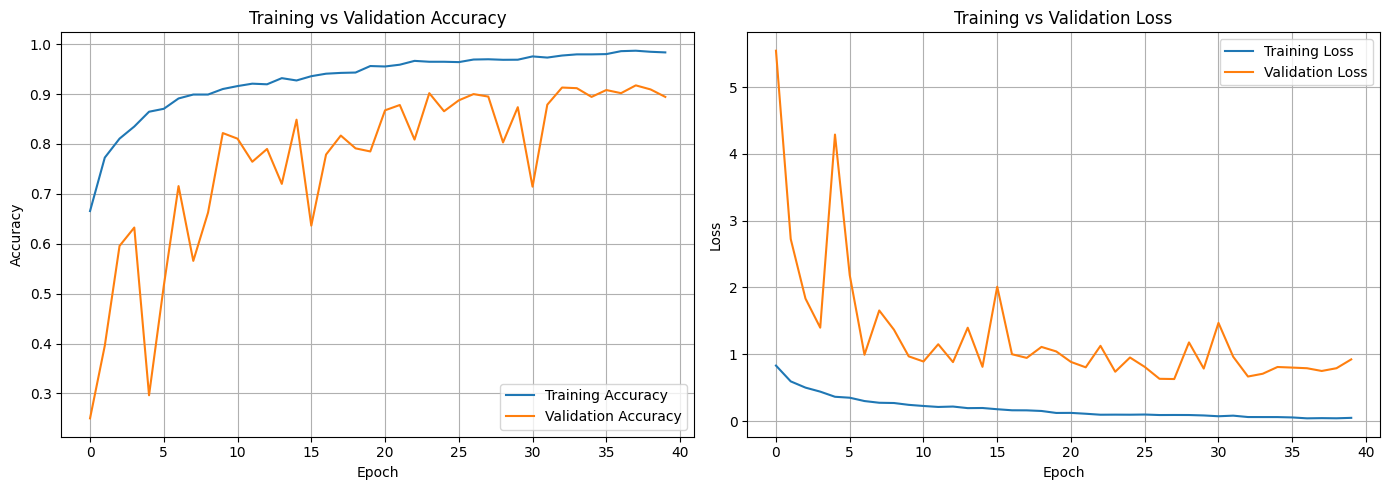


Final Training Accuracy: 98.36%
Best Validation Accuracy: 91.75%

⚠️ Mild overfitting - gap is 6.61%, but val accuracy is above 90% target


In [ ]:
# plotting accuracy and loss curves to check for overfitting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Training vs Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Training vs Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\nFinal Training Accuracy: {:.2f}%".format(history.history['accuracy'][-1] * 100))
print("Best Validation Accuracy: {:.2f}%".format(max(history.history['val_accuracy']) * 100))

gap = history.history['accuracy'][-1] - max(history.history['val_accuracy'])
if gap < 0.05:
    print("\n✅ No significant overfitting - gap is only {:.2f}%".format(gap * 100))
elif gap < 0.10:
    print("\n⚠️ Mild overfitting - gap is {:.2f}%, but val accuracy is above 90% target".format(gap * 100))
else:
    print("\n⚠️ Overfitting detected - gap is {:.2f}%".format(gap * 100))

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9175 - loss: 0.7496

Test Accuracy: 91.75%
Test Loss: 0.7496
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


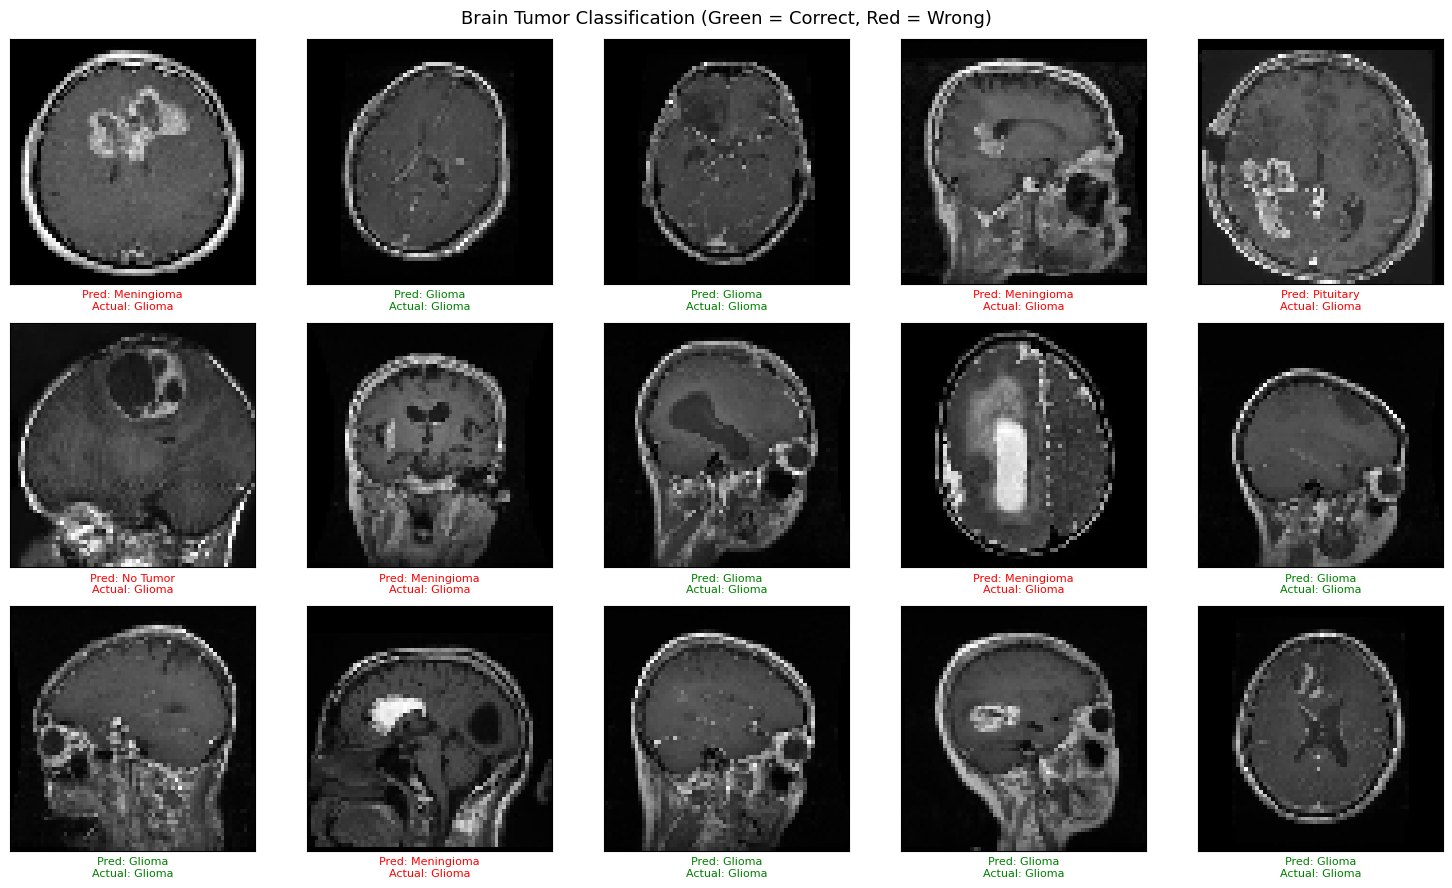

In [ ]:
# evaluating on test data
test_loss, test_accuracy = model.evaluate(test_data, verbose=1)
print("\nTest Accuracy: {:.2f}%".format(test_accuracy * 100))
print("Test Loss: {:.4f}".format(test_loss))

# visualizing some predictions
class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
test_data.reset()
test_images, test_labels = next(iter(test_data))
predictions = model.predict(test_images)

plt.figure(figsize=(15, 9))
for i in range(15):
    plt.subplot(3, 5, i+1)
    plt.imshow(test_images[i].reshape(64, 64), cmap='gray')
    predicted = class_names[np.argmax(predictions[i])]
    actual = class_names[int(test_labels[i])]
    color = 'green' if predicted == actual else 'red'
    plt.xlabel(f"Pred: {predicted}\nActual: {actual}", color=color, fontsize=8)
    plt.xticks([])
    plt.yticks([])
plt.suptitle("Brain Tumor Classification (Green = Correct, Red = Wrong)", fontsize=13)
plt.tight_layout()
plt.show()

Classification Report:

              precision    recall  f1-score   support

      Glioma       0.99      0.76      0.86       400
  Meningioma       0.93      0.91      0.92       400
    No Tumor       0.88      1.00      0.93       400
   Pituitary       0.89      1.00      0.94       400

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600



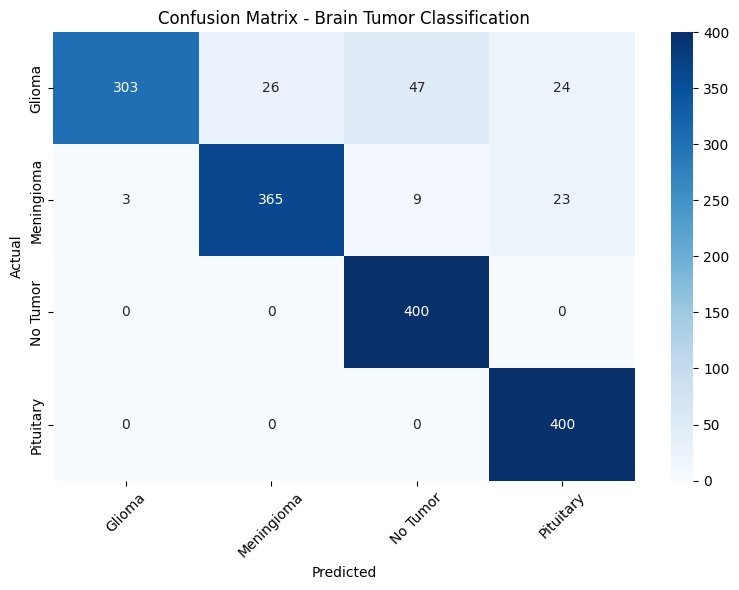


✅ Final Test Accuracy: 91.75% (Target was 90%)


In [ ]:
# classification report and confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

test_data.reset()
y_pred = []
y_true = []

for i in range(len(test_data)):
    images, labels = test_data[i]
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.astype(int))

y_pred = np.array(y_pred)
y_true = np.array(y_true)

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Brain Tumor Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n✅ Final Test Accuracy: {:.2f}% (Target was 90%)".format(test_accuracy * 100))